In [1]:
!pip install -q venn-abers && pip install -q cir-model

  Preparing metadata (setup.py) ... done


In [2]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from venn_abers import VennAbersCalibrator
from cir_model import CenteredIsotonicRegression

from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import (
                LogisticRegression, LogisticRegressionCV, LinearRegression,
                Ridge, RidgeCV, RidgeClassifierCV, BayesianRidge
)

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, r2_score, PredictionErrorDisplay

from tqdm.notebook import tqdm
from time import time
import warnings

## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

2026-03-02 00:31:10.558633: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772411470.828258      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772411470.902605      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772411471.526764      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772411471.526827      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772411471.526830      17 computation_placer.cc:177] computation placer alr

CLASSIC  GREEN   YELLOW 


## 1.__LOAD DATA

In [3]:
PATH   = '/kaggle/input/competitions/playground-series-s6e2/'

train  = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
TARGET = train.columns[-1]

train[TARGET] = train[TARGET].map({'Presence': 1, 'Absence': 0})

submit = pd.read_csv(PATH+'sample_submission.csv')
y_true = train[TARGET].to_numpy()

print(f"✓ DATA LOAD COMPLETE!")

✓ DATA LOAD COMPLETE!


In [4]:
## -- Append predicted columns as extra features --
## -- os.walk: Deep search with subfolders --
def dataloader(filepath, train_prefix, test_prefix):    
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    
    print('Loading .npy files: ', end='')
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%5 == 0: print(f'{i}%.. ', end='')
            if file.endswith('.npy') and train_prefix in file:
                train_path = np.load(os.path.join(root, file))
                train_df = pd.concat([train_df, pd.Series(train_path, name=file[4:-4])], axis=1)
            elif file.endswith('.npy') and test_prefix in file:
                test_path = np.load(os.path.join(root, file))
                test_df = pd.concat([test_df, pd.Series(test_path, name=file[5:-4])], axis=1)
    print()

    print('Loading .parquet files: ', end='')
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%5 == 0: print(f"{i}%.. ", end="")
            if file.endswith('.parquet') and train_prefix in file:
                train_path = os.path.join(root, file)
                train_df = pd.concat([train_df, pd.read_parquet(train_path)], axis=1)
            elif file.endswith('.parquet') and test_prefix in file:
                test_path = os.path.join(root, file)
                test_df = pd.concat([test_df, pd.read_parquet(test_path)], axis=1)
    print()
    print(f"Total oof  models: {len(train_df.columns)} || Shape: {train_df.shape}")
    print(f"Total pred models: {len(test_df.columns)} || Shape: {test_df.shape}")
    print()

    return train_df, test_df

In [5]:
def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols
    print(f"{YELLOW}Columns fixed!!!{RESET}")

    return df_renamed


In [6]:
PATHS = [
    '/kaggle/input/datasets/',
]

## -- Load dataframes --
oofs = []
preds  = []

## -- Load train/test datasets --
for p in PATHS:
    tr, ts = dataloader(p, 'oof', 'test')
    oofs.append(tr)
    preds.append(ts)

## -- Concat datasets --
oof_df = pd.concat(oofs, axis=1)
pred_df  = pd.concat(preds, axis=1)

print('OOF/TEST shape:', oof_df.shape, pred_df.shape)

# ## -- Drop models if necessary --
# for c in oof_df.columns:
#     if 'L2' in c or 'L3' in c: #
#         oof_df.drop([c], axis=1, inplace=True)
#         pred_df.drop([c], axis=1, inplace=True)
#     elif c == TARGET:
#         oof_df.drop([c], axis=1, inplace=True)
        
print('-'*50)

## -- Check for missingness --
print(f'Train Null values: {oof_df.isna().sum().sum()}')
print(f'Test  Null values: {pred_df.isna().sum().sum()}')

print('-'*50)

## -- Apply column rename function --
oof_df = rename_duplicate_cols(oof_df)
pred_df = rename_duplicate_cols(pred_df)

print()

display(oof_df.head(3))
print()
display(pred_df.head(3))

Loading .npy files: 5%.. 10%.. 15%.. 20%.. 25%.. 30%.. 35%.. 40%.. 45%.. 50%.. 55%.. 
Loading .parquet files: 5%.. 10%.. 15%.. 20%.. 25%.. 30%.. 35%.. 40%.. 45%.. 50%.. 55%.. 
Total oof  models: 131 || Shape: (630000, 131)
Total pred models: 131 || Shape: (270000, 131)

OOF/TEST shape: (630000, 131) (270000, 131)
--------------------------------------------------
Train Null values: 0
Test  Null values: 0
--------------------------------------------------


Fixing columns:   0%|          | 0/131 [00:00<?, ?it/s]

Columns fixed!!!


Fixing columns:   0%|          | 0/131 [00:00<?, ?it/s]

Columns fixed!!!



,pytabV1_realMLP_955522,pytabV1_realMLP_955665,pytabV1_tabM_955693,pytabV2nn_mlpPLR_954599,pytabV2nn_realMLP_955483,pytabV2nn_tabM_955677,BARTZv1w_42_953596,BARTZv1w_777_953514,BARTZv1w_1234_95352,BARTZv1w_24611_953578,BARTZv1w_0_953541,CAT_plain_v1BAYES_42_955707,CAT_plain_v1BERN_42_955477,CAT_plain_v1LOSS_42_955608,CAT_order_v1BAYES_42_955717,CAT_plain_v2BAYES_777_955702,CAT_plain_v2BERN_777_955469,CAT_plain_v2LOSS_777_955598,CAT_order_v2BAYES_777_955709,CAT_plain_v3BAYES_24611_955704,HISTv1_42_955525,HISTv1_777_955536,HISTv1_1234_955527,HISTv1_24611_955512,HISTv1_0_955518,LGBv1BAG_31_005_42_955677,LGBv1BAG_31_005_777_955672,LGBv1BAG_31_005_1234_955674,LGBv1BAG_31_005_24611_955668,LGBv1GOSS_31_005_42_955675,LGBv1GOSS_31_005_777_955671,LGBv1GOSS_31_005_1234_955673,LGBv1GOSS_31_005_24611_95567,LGBv2BAG_01_42_955676,LGBv2BAG_777_955682,LGBv2BAG_1234_955676,LGBv2BAG_24611_955679,LGBv2BAG_0_955683,LGBv2GOSS_01_42_955679,LGBv2GOSS_777_955683,LGBv2GOSS_1234_955677,LGBv2GOSS_24611_955678,LGBv2GOSS_0_955685,LGBv3BAG_01_42_955669,LGBv3BAG_777_955678,LGBv3BAG_1234_955679,LGBv3BAG_24611_955674,LGBv3BAG_0_95568,LGBv3GOSS_01_42_955714,LGBv3GOSS_777_955723,LGBv3GOSS_1234_955714,LGBv3GOSS_24611_955717,LGBv3GOSS_0_955716,LGBv3_fixBAG_fix_42_955713,LGBv3_fixBAG_fix_777_955722,LGBv3_fixBAG_fix_1234_955711,LGBv3_fixBAG_fix_24611_955715,LGBv3_fixBAG_fix_0_955713,LGBv4BAG_42_955706,LGBv4BAG_777_9557,LGBv4BAG_1234_955706,LGBv4BAG_24611_955697,LGBv4BAG_0_955702,LGBv4GOSS_42_955705,LGBv4GOSS_777_955698,LGBv4GOSS_1234_955707,LGBv4GOSS_24611_955699,LGBv4GOSS_0_955698,LGBv5BAG_42_955684,LGBv5BAG_777_9557,LGBv5BAG_1234_955708,LGBv5BAG_24611_955702,LGBv5BAG_0_955702,LGBv5GOSS_42_955684,LGBv5GOSS_777_955699,LGBv5GOSS_1234_955707,LGBv5GOSS_24611_955699,LGBv5GOSS_0_955703,LOGv1_ohe_all_955517,LOGv1_ohe_all_drop_none_955526,TabNETv1_42_955091,XGBv1GBT_42_955717,XGBv1GBT_777_95572,XGBv1GBT_1234_955719,XGBv1GBT_24611_955719,XGBv1GBT_0_955717,XGBv1LOSS_4_42_955698,XGBv1LOSS_777_955698,XGBv1LOSS_1234_9557,XGBv1LOSS_24611_955696,XGBv1LOSS_0_955697,XGBv1GRAD_42_955715,XGBv1GRAD_777_95571,XGBv1GRAD_1234_955717,XGBv1GRAD_24611_955715,XGBv1GRAD_0_955717,XGBv2GBT_42_955722,XGBv2GBT_777_955723,XGBv2GBT_1234_955722,XGBv2GBT_24611_955721,XGBv2GBT_0_955722,XGBv2LOSS_4_42_955703,XGBv2LOSS_777_9557,XGBv2LOSS_1234_955702,XGBv2LOSS_24611_955698,XGBv2LOSS_0_955703,XGBv2GRAD_42_955716,XGBv2GRAD_777_955722,XGBv2GRAD_1234_955718,XGBv2GRAD_24611_955716,XGBv2GRAD_0_955715,XGBv3GBT_42_955682,XGBv3GBT_777_955682,XGBv3GBT_1234_955683,XGBv3GBT_24611_955683,XGBv3GBT_0_955677,XGBv3LOSS_42_955686,XGBv3LOSS_777_955689,XGBv3LOSS_1234_955688,XGBv3LOSS_24611_955687,XGBv3LOSS_0_955685,XLEARNv1_fm_955651,XLEARNv2_linear_955525,XLEARNv2_fm_955653,XLEARNv3_fm_95566,XLEARNv3_ffm_95552,XLEARNv3_linear_955543,YDFv1_local_42_955533,YDFv1_global_42_955533,xgb_tabM_pseudo_955705,xgb_tabM_pseudo_955718
0,0.948943,0.994271,0.997665,0.998774,0.949808,0.998040,1.024284,0.998312,1.000147,1.003344,1.008991,0.997356,0.996361,0.996653,0.997288,0.997419,0.996472,0.996869,0.997415,0.997282,0.994924,0.994925,0.994422,0.995296,0.995136,0.996346,0.996481,0.996442,0.996632,0.996300,0.996630,0.996684,0.996454,0.996810,0.997106,0.996695,0.996583,0.996408,0.996692,0.996958,0.996792,0.996849,0.996570,0.996482,0.996111,0.995996,0.996302,0.996196,0.998250,0.998192,0.998299,0.998276,0.998329,0.998264,0.998234,0.998292,0.998230,0.998280,0.998306,0.998069,0.998281,0.998064,0.998085,0.998241,0.998013,0.998254,0.998047,0.998084,0.997959,0.997986,0.997946,0.998091,0.997960,0.997982,0.998028,0.997933,0.998064,0.997901,0.998195,0.998116,0.999321,0.997869,0.997953,0.997876,0.997884,0.997901,0.997323,0.997308,0.997395,0.997420,0.997371,0.997822,0.997891,0.997963,0.997926,0.997932,0.998095,0.998058,0.998071,0.998058,0.997969,0.997447,0.997515,0.997554,0.997457,0.997463,0.998178,0.998202,0.998220,0.998164,0.998166,0.998009,0.998030,0.998101,0.997821,0.998069,0.998105,0.998197,0.998039,0.998030,0.998128,0.998406,0.998211,0.998400,0.99

,pytabV1_realMLP_955522,pytabV1_realMLP_955665,pytabV1_tabM_955693,pytabV2nn_mlpPLR_954599,pytabV2nn_realMLP_955483,pytabV2nn_tabM_955677,BARTZv1w_42_953596,BARTZv1w_777_953514,BARTZv1w_1234_95352,BARTZv1w_24611_953578,BARTZv1w_0_953541,CAT_plain_v1BAYES_42_955707,CAT_plain_v1BERN_42_955477,CAT_plain_v1LOSS_42_955608,CAT_order_v1BAYES_42_955717,CAT_plain_v2BAYES_777_955702,CAT_plain_v2BERN_777_955469,CAT_plain_v2LOSS_777_955598,CAT_order_v2BAYES_777_955709,CAT_plain_v3BAYES_24611_955704,HISTv1_42_955525,HISTv1_777_955536,HISTv1_1234_955527,HISTv1_24611_955512,HISTv1_0_955518,LGBv1BAG_31_005_42_955677,LGBv1BAG_31_005_777_955672,LGBv1BAG_31_005_1234_955674,LGBv1BAG_31_005_24611_955668,LGBv1GOSS_31_005_42_955675,LGBv1GOSS_31_005_777_955671,LGBv1GOSS_31_005_1234_955673,LGBv1GOSS_31_005_24611_95567,LGBv2BAG_01_42_955676,LGBv2BAG_777_955682,LGBv2BAG_1234_955676,LGBv2BAG_24611_955679,LGBv2BAG_0_955683,LGBv2GOSS_01_42_955679,LGBv2GOSS_777_955683,LGBv2GOSS_1234_955677,LGBv2GOSS_24611_955678,LGBv2GOSS_0_955685,LGBv3BAG_01_42_955669,LGBv3BAG_777_955678,LGBv3BAG_1234_955679,LGBv3BAG_24611_955674,LGBv3BAG_0_95568,LGBv3GOSS_01_42_955714,LGBv3GOSS_777_955723,LGBv3GOSS_1234_955714,LGBv3GOSS_24611_955717,LGBv3GOSS_0_955716,LGBv3_fixBAG_fix_42_955713,LGBv3_fixBAG_fix_777_955722,LGBv3_fixBAG_fix_1234_955711,LGBv3_fixBAG_fix_24611_955715,LGBv3_fixBAG_fix_0_955713,LGBv4BAG_42_955706,LGBv4BAG_777_9557,LGBv4BAG_1234_955706,LGBv4BAG_24611_955697,LGBv4BAG_0_955702,LGBv4GOSS_42_955705,LGBv4GOSS_777_955698,LGBv4GOSS_1234_955707,LGBv4GOSS_24611_955699,LGBv4GOSS_0_955698,LGBv5BAG_42_955684,LGBv5BAG_777_9557,LGBv5BAG_1234_955708,LGBv5BAG_24611_955702,LGBv5BAG_0_955702,LGBv5GOSS_42_955684,LGBv5GOSS_777_955699,LGBv5GOSS_1234_955707,LGBv5GOSS_24611_955699,LGBv5GOSS_0_955703,LOGv1_ohe_all_955517,LOGv1_ohe_all_drop_none_955526,TabNETv1_42_955091,XGBv1GBT_42_955717,XGBv1GBT_777_95572,XGBv1GBT_1234_955719,XGBv1GBT_24611_955719,XGBv1GBT_0_955717,XGBv1LOSS_4_42_955698,XGBv1LOSS_777_955698,XGBv1LOSS_1234_9557,XGBv1LOSS_24611_955696,XGBv1LOSS_0_955697,XGBv1GRAD_42_955715,XGBv1GRAD_777_95571,XGBv1GRAD_1234_955717,XGBv1GRAD_24611_955715,XGBv1GRAD_0_955717,XGBv2GBT_42_955722,XGBv2GBT_777_955723,XGBv2GBT_1234_955722,XGBv2GBT_24611_955721,XGBv2GBT_0_955722,XGBv2LOSS_4_42_955703,XGBv2LOSS_777_9557,XGBv2LOSS_1234_955702,XGBv2LOSS_24611_955698,XGBv2LOSS_0_955703,XGBv2GRAD_42_955716,XGBv2GRAD_777_955722,XGBv2GRAD_1234_955718,XGBv2GRAD_24611_955716,XGBv2GRAD_0_955715,XGBv3GBT_42_955682,XGBv3GBT_777_955682,XGBv3GBT_1234_955683,XGBv3GBT_24611_955683,XGBv3GBT_0_955677,XGBv3LOSS_42_955686,XGBv3LOSS_777_955689,XGBv3LOSS_1234_955688,XGBv3LOSS_24611_955687,XGBv3LOSS_0_955685,XLEARNv1_fm_955651,XLEARNv2_linear_955525,XLEARNv2_fm_955653,XLEARNv3_fm_95566,XLEARNv3_ffm_95552,XLEARNv3_linear_955543,YDFv1_local_42_955533,YDFv1_global_42_955533,xgb_tabM_pseudo_955705,xgb_tabM_pseudo_955718
0,0.902585,0.947821,0.954393,0.953737,0.900125,0.957686,0.938856,0.928100,0.932958,0.925692,0.936459,0.944083,0.951161,0.956541,0.942709,0.942919,0.951514,0.957654,0.941972,0.944004,0.956028,0.956708,0.954753,0.958349,0.949735,0.953561,0.954959,0.953434,0.953535,0.953509,0.955099,0.953605,0.952829,0.950850,0.950714,0.949169,0.948882,0.948596,0.950606,0.951389,0.949201,0.949233,0.949779,0.958578,0.956693,0.957628,0.957349,0.956037,0.944494,0.945037,0.945360,0.946676,0.946165,0.944558,0.944397,0.944862,0.946337,0.945545,0.937115,0.947641,0.939485,0.948503,0.947052,0.937594,0.947361,0.939440,0.948290,0.947219,0.942819,0.943455,0.943790,0.945365,0.945546,0.943275,0.943397,0.943953,0.945099,0.945802,0.941535,0.940509,0.941972,0.945144,0.945656,0.945265,0.945758,0.944958,0.945689,0.945039,0.945178,0.944512,0.945021,0.945078,0.944141,0.944356,0.944848,0.944372,0.946030,0.945399,0.945593,0.945698,0.946118,0.945648,0.945180,0.945547,0.944772,0.946200,0.945510,0.944874,0.944839,0.945597,0.945183,0.936953,0.937192,0.936831,0.936797,0.937124,0.939650,0.937769,0.938553,0.938384,0.938788,0.949838,0.941724,0.950066,0.95

In [7]:
## -- Confirm feature names consistency --
for i, enum in enumerate([oof_df.columns == pred_df.columns]):
    print(i, enum)

0 [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True]


In [8]:
for k, v in zip(oof_df.columns, pred_df.columns):
    print(f"{k:<25} ---| {v}")

pytabV1_realMLP_955522    ---| pytabV1_realMLP_955522
pytabV1_realMLP_955665    ---| pytabV1_realMLP_955665
pytabV1_tabM_955693       ---| pytabV1_tabM_955693
pytabV2nn_mlpPLR_954599   ---| pytabV2nn_mlpPLR_954599
pytabV2nn_realMLP_955483  ---| pytabV2nn_realMLP_955483
pytabV2nn_tabM_955677     ---| pytabV2nn_tabM_955677
BARTZv1w_42_953596        ---| BARTZv1w_42_953596
BARTZv1w_777_953514       ---| BARTZv1w_777_953514
BARTZv1w_1234_95352       ---| BARTZv1w_1234_95352
BARTZv1w_24611_953578     ---| BARTZv1w_24611_953578
BARTZv1w_0_953541         ---| BARTZv1w_0_953541
CAT_plain_v1BAYES_42_955707 ---| CAT_plain_v1BAYES_42_955707
CAT_plain_v1BERN_42_955477 ---| CAT_plain_v1BERN_42_955477
CAT_plain_v1LOSS_42_955608 ---| CAT_plain_v1LOSS_42_955608
CAT_order_v1BAYES_42_955717 ---| CAT_order_v1BAYES_42_955717
CAT_plain_v2BAYES_777_955702 ---| CAT_plain_v2BAYES_777_955702
CAT_plain_v2BERN_777_955469 ---| CAT_plain_v2BERN_777_955469
CAT_plain_v2LOSS_777_955598 ---| CAT_plain_v2LOSS_777_95559

In [9]:
print(f"""
-> OOFS shape: {oof_df.shape}
-> TEST shape: {pred_df.shape}
-> y_true    : {y_true.shape}
    """)


-> OOFS shape: (630000, 131)
-> TEST shape: (270000, 131)
-> y_true    : (630000,)
    


In [10]:
## -- CIR/IR --
# try:
#     from cir_model import CenteredIsotonicRegression
# except:
#     %pip install -qq -U cir-model
#     from cir_model import CenteredIsotonicRegression

# from sklearn.isotonic import IsotonicRegression
# from cir_model import CenteredIsotonicRegression

# CIR_oof_df = pd.DataFrame()
# CIR_pred_df = pd.DataFrame()
# for c in oof_df.columns:
#     CIR = CenteredIsotonicRegression(out_of_bounds='clip').fit(oof_df[c], y_true)
#     CIR_oof_df[c]  = CIR.transform(oof_df[c])
#     CIR_pred_df[c] = CIR.transform(pred_df[c])

# IR_oof_df = pd.DataFrame()
# IR_pred_df = pd.DataFrame()
# for c in oof_df.columns:
#     IR = IsotonicRegression(out_of_bounds='clip').fit(oof_df[c], y_true)
#     IR_oof_df[c]  = IR.transform(oof_df[c])
#     IR_pred_df[c] = IR.transform(pred_df[c])

# CIR, IR

# fig, axs = plt.subplots(1, 3, figsize=(20, 5))
# sns.histplot(oof_df.iloc[:, 0], ax=axs[0]).set_title("Original")
# sns.histplot(IR_oof_df.iloc[:, 0], ax=axs[1]).set_title("Isotonic Regression")
# sns.histplot(CIR_oof_df.iloc[:, 0], ax=axs[2]).set_title("Centered Isotonic Regression")
# plt.show()

# pd.concat([oof_df.iloc[:, 0], IR_oof_df.iloc[:, 0], CIR_oof_df.iloc[:, 0]], axis=1).head()

# ENSEMBLE 1: STACKING

In [11]:
def train_meta(oof_df, pred_df, features, y_true, clf='ridge', kf_splits=5, n_cv=5, n_alphas=10):
    ## -- Stack with RidgeCV meta_model --
    kf = StratifiedKFold(n_splits=kf_splits, shuffle=True, random_state=SEED)

    oof_preds  = np.zeros(oof_df.shape[0])
    test_preds = np.zeros(pred_df.shape[0])

    val_scores = []
    oof_alphas = []

    if clf == 'log':
        print(f"===== LOGISTIC {kf_splits} FOLDS =====")
    else:
        print(f"===== RIDGE {kf_splits} FOLDS =====")
        
    for fold, (trn_idx, val_idx) in enumerate(kf.split(oof_df, y_true)):
                                                      
        X_trn, y_trn = oof_df[features].iloc[trn_idx], y_true[trn_idx]
        X_val, y_val = oof_df[features].iloc[val_idx], y_true[val_idx]

        if clf == 'log':
            model = LogisticRegressionCV(
                Cs=np.logspace(-15, 2, n_alphas),
                max_iter=1000,
                scoring='neg_log_loss',
                cv=n_cv,
                n_jobs=os.cpu_count(),
            )
            model.fit(X_trn, y_trn)

            oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
            test_preds += model.predict_proba(pred_df[features])[:, 1]
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))
            
            print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.6f} | ", end='')
            print(f"Best C: {model.C_}")
        else:
            model = RidgeCV(
                alphas=np.logspace(0, 2, n_alphas),
                scoring='neg_root_mean_squared_error',
                cv=n_cv,
            )
            model.fit(X_trn, y_trn)
            ridge_score = np.round(-model.best_score_, 6)
            oof_preds[val_idx] = model.predict(X_val)
            test_preds += model.predict(pred_df[features])
            val_scores.append(roc_auc_score(y_val, oof_preds[val_idx]))

            print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.6f} | ", end='')
            print(f"Best Alpha: {model.alpha_:.4f}")
            oof_alphas.append(model.alpha_)
    test_preds /= kf.n_splits
    

    final_auc = np.round(roc_auc_score(y_true, oof_preds), 6)
    print(f"\n{'='*35}")
    print(f"✅ STACKING AUC: {final_auc}")
    print("="*35)

    ## -- REFIT ON FULL --
    return test_preds, oof_preds, final_auc

===== RIDGE 15 FOLDS =====
Fold 1/15: 0.956310 | Best Alpha: 8.8587
Fold 2/15: 0.956231 | Best Alpha: 6.9519
Fold 3/15: 0.956055 | Best Alpha: 5.4556
Fold 4/15: 0.955720 | Best Alpha: 6.9519
Fold 5/15: 0.954521 | Best Alpha: 6.9519
Fold 6/15: 0.954977 | Best Alpha: 6.9519
Fold 7/15: 0.955957 | Best Alpha: 6.9519
Fold 8/15: 0.956209 | Best Alpha: 6.9519
Fold 9/15: 0.955479 | Best Alpha: 6.9519
Fold 10/15: 0.955139 | Best Alpha: 8.8587
Fold 11/15: 0.955014 | Best Alpha: 8.8587
Fold 12/15: 0.956415 | Best Alpha: 8.8587
Fold 13/15: 0.957065 | Best Alpha: 11.2884
Fold 14/15: 0.955872 | Best Alpha: 6.9519
Fold 15/15: 0.956153 | Best Alpha: 8.8587

✅ STACKING AUC: 0.955798

(630000,) (270000,)


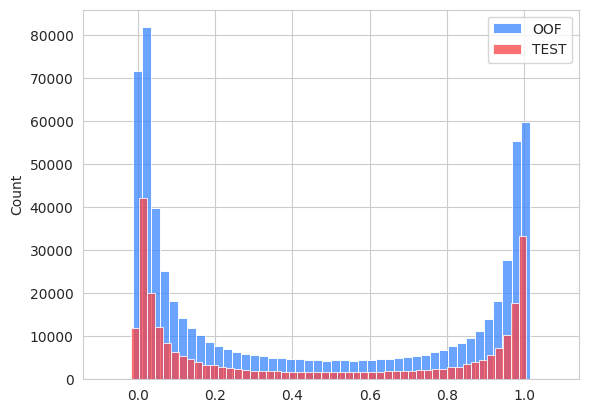

CPU times: user 51min 8s, sys: 5min 18s, total: 56min 26s
Wall time: 24min 9s


,id,Heart Disease
0,630000,0.952763
1,630001,0.005096
2,630002,0.991753
3,630003,0.003100
4,630004,0.196700


In [12]:
%%time

## ======== RIDGE CV ========
test_ridge, oof_ridge, ridge_score = train_meta(
    clf='ridge',
    oof_df=oof_df,
    pred_df=pred_df,
    features=oof_df.columns,
    y_true=y_true,
    n_cv=5,
    kf_splits=15,
    n_alphas=20,
)
print()

print(oof_ridge.shape, test_ridge.shape)

## -- Distribution Plots --
# sns.histplot(y_true, label='True', bins=80)
sns.histplot(oof_ridge, label='OOF', bins=50)
sns.histplot(test_ridge, label='TEST', bins=50)
plt.legend()
plt.show()

submit[TARGET] = test_ridge
submit.to_csv(f"submit_ridge_stackCV_{str(ridge_score).split('.')[1]}.csv", index=False)
submit.head()

In [13]:
# %%time

# ## ======== LOGISTIC CV ========
# test_logit, oof_logit, logit_score = train_meta(
#     clf='log',
#     oof_df=oof_df,
#     pred_df=pred_df,
#     features=oof_df.columns,
#     y_true=y_true,
#     n_cv=5,
#     kf_splits=15,
#     n_alphas=20,
# )
# print()

# print(oof_logit.shape, test_logit.shape)

# ## -- Distribution Plots --
# # sns.histplot(y_true, label='True', bins=80)
# sns.histplot(oof_logit, label='OOF', bins=80)
# sns.histplot(test_logit, label='TEST', bins=80)
# plt.legend()
# plt.show()

# submit[TARGET] = test_logit
# submit.to_csv(f"submit_logit_stackCV_{str(logit_score).split('.')[1]}.csv", index=False)
# submit.head()

In [14]:
%%time

## -- TRAIN ON FULL DATA --
clf = RidgeCV(alphas=np.logspace(0, 2, 20), scoring='neg_root_mean_squared_error', cv=15)
clf.fit(oof_df, y_true)

clf_score = np.round(-clf.best_score_, 6)

## -- MAKE SUBMISSION --
n = f"submit_ridge_stackFULL_{str(clf_score).split('.')[1]}.csv"
submit[TARGET] = clf.predict(pred_df)
submit.to_csv(n, index=False)

print('Submission File Exported -> ', n)
submit.head()

Submission File Exported ->  submit_ridge_stackFULL_284213.csv
CPU times: user 11min 40s, sys: 1min 10s, total: 12min 51s
Wall time: 5min 35s


,id,Heart Disease
0,630000,0.952994
1,630001,0.005020
2,630002,0.991721
3,630003,0.003114
4,630004,0.196686


In [15]:
# clf = LogisticRegressionCV(scoring='roc_auc', cv=5, max_iter=1000, random_state=SEED)
# clf.fit(oof_df, y_true)

# clf.score_ 

In [16]:
# %%time

# ## -- CALIBRATION FIT --
# VAC_clf = VennAbersCalibrator(estimator=clf, inductive=False, n_splits=5)
# VAC_clf.fit(oof_df, y_true)

# clf_score = np.round(roc_auc_score(y_true, VAC_clf.predict(oof_df)), 6)
# clf_score

In [17]:
# ## -- MAKE SUBMISSION --
# predictions_CVAP = VAC_clf.predict(pred_df)

# submit[TARGET] = predictions_CVAP
# submit.to_csv(f"submit_venn_calib_{str(clf_score).split('.')[1]}.csv", index=False)
# submit.head()

# ENSEMBLE 2: HILL CLIMBING

In [18]:
try:
    from hillclimbers import climb_hill, partial
except:
    %pip install -qq hillclimbers
    from hillclimbers import climb_hill, partial

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [19]:
%%time
test_hillclimb, oof_hillclimb= climb_hill(
                               train = train,
                              target = TARGET,
                         oof_pred_df = oof_df[oof_df.columns],
                        test_pred_df = pred_df[oof_df.columns],
                           objective = "maximize",
                         eval_metric = partial(roc_auc_score),
                    # negative_weights = True,
                    return_oof_preds = True,
                           precision = 0.01,
                           plot_hill = True,
                           plot_hist = False,
    )

# 0.957941

   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (131 total): 

LGBv3GOSS_777_955723:           0.95572 (best solo model)
XGBv2GBT_777_955723:            0.95572
XGBv2GRAD_777_955722:           0.95572
XGBv2GBT_0_955722:              0.95572
LGBv3_fixBAG_fix_777_955722:    0.95572
XGBv2GBT_1234_955722:           0.95572
XGBv2GBT_42_955722:             0.95572
XGBv2GBT_24611_955721:          0.95572
XGBv1GBT_777_95572:             0.95572
XGBv1GBT_24611_955719:          0.95572
XGBv1GBT_1234_955719:           0.95572
XGBv2GRAD_1234_955718:          0.95572
xgb_tabM_pseudo_955718:         0.95572
LGBv3GOSS_24611_955717:         0.95572
CAT_order_v1BAYES_42_955717:    0.95572
XGBv1GRAD_1234_955717:          0.95572
XGBv1GRAD_0_955717:             0.95572
XGBv1GBT_42_955717:             0.95572
XGBv1GBT_0_955717:              0.95572
XGBv2GRAD_24611_955716:         0.95572
XGBv2GRAD_42_955716:            0.95572
LGBv3GOSS_0_955716:             0.95572
XGBv1GRAD_246

CPU times: user 3h 55min 48s, sys: 28.1 s, total: 3h 56min 16s
Wall time: 3h 56min 20s


In [20]:
hillclimb_score = np.round(roc_auc_score(y_true, oof_hillclimb), 6)

print(f"-> Hillclimb Score: {hillclimb_score}")
print(f"""\n
-> TRUE Avg.: {np.mean(y_true):.5f}
-> OOFS Avg.: {np.mean(oof_hillclimb):.5f}
-> TEST Avg.: {np.mean(test_hillclimb):.5f}
    """)

## -- SUBMISSION FILE --
n = f"submit_hillclimb_{str(hillclimb_score).split('.')[1]}.csv"
submit[TARGET] = test_hillclimb
submit.to_csv(n, index=False)

print('Submission File Exported -> ', n)
submit.head()

-> Hillclimb Score: 0.955794


-> TRUE Avg.: 0.44834
-> OOFS Avg.: 0.44843
-> TEST Avg.: 0.44996
    
Submission File Exported ->  submit_hillclimb_955794.csv


,id,Heart Disease
0,630000,0.948311
1,630001,0.007986
2,630002,0.991300
3,630003,0.004344
4,630004,0.198884


# ENSEMBLE 3: OPTIMIZED BLENDING WITH SCIPY

In [21]:
# from scipy.optimize import minimize
# np.random.seed(SEED)

In [22]:
# columns = ['ridge_'+str(ridge_score_new), 'hillclimb_'+str(hillclimb_score)]

# train_final = pd.DataFrame(dict(zip(columns, [oof_ridge, oof_hillclimb])))
# test_final  = pd.DataFrame(dict(zip(columns, [test_ridge, test_hillclimb])))

# train_final.shape, test_final.shape

In [23]:
# display(train_final.head())
# print()
# display(test_final .head())

In [24]:
# blend_train = []
# blend_test = []

# for col in train_final:
#     blend_train.append(train_final[col])
# blend_train = np.array(blend_train)

# for col in test_final:
#     blend_test.append(test_final[col])
# blend_test = np.array(blend_test)

# print(len(blend_train), len(blend_test))

# a = 0.12345
# print("{0:.2f}".format(a))

In [25]:
# # BLOCK 2 - AUC-based objective and optimization
# def roc_min_func(weights):
#     final_prediction = np.tensordot(weights, blend_train, axes=(0, 0))
#     return roc_auc_score(y_true, final_prediction)
    
# print("\n Finding Blending Weights (AUC objective)...")
# res_list = []
# weights_list = []

# n_models = blend_train.shape[0]

# for k in range(100):  # Optimization rounds
#     starting_values = np.random.uniform(size=n_models)
#     bounds = [(0, 1)] * n_models

#     res = minimize(
#         roc_min_func,
#         starting_values,
#         method="L-BFGS-B",
#         bounds=bounds,
#         options={"disp": False, "maxiter": 100000},
#     )

#     res_list.append(res["fun"])
#     weights_list.append(res["x"])

#     res_fun = format(res["fun"], '.5f')
#     items = [format(item, '.6f') for item in res["x"]]

#     print(
#         "{iter}\tScore: {score}\tWeights: {weights}".format(
#             iter=(k + 1),
#             score=res_fun,
#             weights="\t".join([str(item) for item in items]),
#         )
#     )

# bestAUC = np.max(res_list)  # higher is better
# bestWght = weights_list[int(np.argmax(res_list))]
# weights = bestWght

# blend_score = round(bestAUC, 6)

In [26]:
# # BLOCK 3 - reporting and final model
# print('Ensemble AUC: {best_score}'.format(best_score=blend_score))
# # print('\n Best Weights: {weights}'.format(weights=bestWght))

# train_prices = np.zeros(len(blend_train[0]))
# test_prices  = np.zeros(len(blend_test[0]))

# print('\n ----------------')
# print(' Weights | Model:')
# print(' ----------------')
# for k in range(len(blend_test)):
#     print(' %.6f * model-%d' % (weights[k], (k + 1)))
#     test_prices += blend_test[k] * weights[k]

# for k in range(len(blend_train)):
#     train_prices += blend_train[k] * weights[k]

# # Optional: normalize weights to sum to 1 (same as before)
# bestWght /= np.sum(bestWght)
# print()

# # BLOCK 4 - optional visualization (unchanged logic)
# optimized_oof = np.tensordot(bestWght, train_final, axes=((0), (1)))  # shape (n_samples,)
# sns.histplot(optimized_oof, bins=50, label=f'Predictions with AUC Optimizer ')
# plt.legend()
# plt.show()

In [27]:
# ## -- APPLY WEIGHTS TO TEST PREDICTIONS --
# optimized_test = test_final.to_numpy().dot(weights)
# submit[TARGET] = optimized_test
# submit.to_csv(f"submit_Optimized_Blend_{str(blend_score).split('.')[1]}.csv", index=False)
# submit.head()